# Deep Learning Model Comparison for ICU Deterioration Prediction
This notebook summarizes the five recommended deep learning models, compares their strengths, and shows how to evaluate them on the ICU deterioration dataset.

## 1. Import Required Libraries
Use Python libraries for data handling, model building, and evaluation.

In [2]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, average_precision_score, confusion_matrix

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 100
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

Using device: cpu


## 2. Load and Prepare Data
Load the ICU dataset, split features and label, and scale the input for deep learning.

In [3]:
TARGET = 'hospital_death'
train = pd.read_csv('data/train.csv')
val = pd.read_csv('data/val.csv')
test = pd.read_csv('data/test.csv')

X_train = train.drop(columns=[TARGET]).values.astype(np.float32)
y_train = train[TARGET].values.astype(np.float32)
X_val = val.drop(columns=[TARGET]).values.astype(np.float32)
y_val = val[TARGET].values.astype(np.float32)
X_test = test.drop(columns=[TARGET]).values.astype(np.float32)
y_test = test[TARGET].values.astype(np.float32)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

print('Shapes:')
print('  X_train', X_train.shape, 'y_train', y_train.shape)
print('  X_val', X_val.shape, 'y_val', y_val.shape)
print('  X_test', X_test.shape, 'y_test', y_test.shape)

Shapes:
  X_train (117318, 134) y_train (117318,)
  X_val (13757, 134) y_val (13757,)
  X_test (13757, 134) y_test (13757,)


## 3. Define Models
Create the candidate deep learning architectures to compare.

In [4]:
class FeedforwardNet(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.network(x).squeeze(1)

class ResidualNet(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.initial = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.BatchNorm1d(512),
            nn.ReLU()
        )
        self.block1 = nn.Sequential(
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 512),
            nn.BatchNorm1d(512)
        )
        self.block2 = nn.Sequential(
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 512),
            nn.BatchNorm1d(512)
        )
        self.output = nn.Linear(512, 1)

    def forward(self, x):
        x = self.initial(x)
        residual = x
        x = self.block1(x) + residual
        x = torch.relu(x)
        residual = x
        x = self.block2(x) + residual
        x = torch.relu(x)
        return self.output(x).squeeze(1)

class AttentionNet(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.embed = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3)
        )
        self.attention_gate = nn.Sequential(
            nn.Linear(256, 256),
            nn.Sigmoid()
        )
        self.decoder = nn.Sequential(
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        x = self.embed(x)
        weights = self.attention_gate(x)
        x = x * weights + x
        return self.decoder(x).squeeze(1)

class MultiHeadAttentionNet(nn.Module):
    def __init__(self, input_dim, num_heads=4):
        super().__init__()
        self.embed = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU()
        )
        self.heads = nn.ModuleList([
            nn.Sequential(
                nn.Linear(256, 256),
                nn.Sigmoid()
            )
            for _ in range(num_heads)
        ])
        self.proj = nn.Linear(256, 256)
        self.decoder = nn.Sequential(
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        x = self.embed(x)
        heads = [x * head(x) for head in self.heads]
        x = torch.stack(heads, dim=0).mean(dim=0)
        x = self.proj(x)
        return self.decoder(x).squeeze(1)

class FeatureInteractionNet(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.main_path = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3)
        )
        self.interaction_path = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU()
        )
        self.fusion = nn.Sequential(
            nn.Linear(384, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        main = self.main_path(x)
        interaction = self.interaction_path(x)
        combined = torch.cat([main, interaction], dim=1)
        return self.fusion(combined).squeeze(1)

## 4. Train Models
Define the dataset, training loop, and a set of candidate models to train.

In [6]:
class ICUDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

BATCH_SIZE = 256
train_loader = DataLoader(ICUDataset(X_train, y_train), batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(ICUDataset(X_val, y_val), batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(ICUDataset(X_test, y_test), batch_size=BATCH_SIZE, shuffle=False)

def train_epoch(model, loader, criterion, optimizer):
    model.train()
    running_loss = 0.0
    for X_batch, y_batch in loader:
        X_batch = X_batch.to(DEVICE)
        y_batch = y_batch.to(DEVICE)
        optimizer.zero_grad()
        logits = model(X_batch)
        loss = criterion(logits, y_batch)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    return running_loss / len(loader)

def evaluate(model, loader, criterion):
    model.eval()
    running_loss = 0.0
    all_labels = []
    all_probs = []
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(DEVICE)
            y_batch = y_batch.to(DEVICE)
            logits = model(X_batch)
            loss = criterion(logits, y_batch)
            running_loss += loss.item()
            probs = torch.sigmoid(logits).cpu().numpy()
            all_probs.extend(probs)
            all_labels.extend(y_batch.cpu().numpy())
    return running_loss / len(loader), np.array(all_labels), np.array(all_probs)

def compute_metrics(y_true, y_pred_proba, threshold=0.5):
    y_pred = (y_pred_proba >= threshold).astype(int)
    auroc = roc_auc_score(y_true, y_pred_proba)
    auprc = average_precision_score(y_true, y_pred_proba)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    sensitivity = tp / (tp + fn) if tp + fn else 0
    specificity = tn / (tn + fp) if tn + fp else 0
    return {
        'AUROC': auroc,
        'AUPRC': auprc,
        'Sensitivity': sensitivity,
        'Specificity': specificity,
        'F1': 2*tp / (2*tp + fp + fn) if (2*tp + fp + fn) else 0,
        'TN': int(tn),
        'FP': int(fp),
        'FN': int(fn),
        'TP': int(tp)
    }

CLASS_WEIGHTS = torch.tensor([float((y_train == 1).sum() / (y_train == 0).sum())], dtype=torch.float32).to(DEVICE)
criterion = nn.BCEWithLogitsLoss(pos_weight=CLASS_WEIGHTS)
MODEL_CLASSES = {
    'Baseline': FeedforwardNet,
    'Residual': ResidualNet,
    'Attention': AttentionNet,
    'MultiHead': MultiHeadAttentionNet,
    'Interaction': FeatureInteractionNet
}

models = {}
for name, ModelClass in MODEL_CLASSES.items():
    model = ModelClass(X_train.shape[1]).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    print(f"\nTraining {name} model...")
    best_val_auc = 0.0
    patience = 8
    wait = 0
    for epoch in range(1, 31):
        train_loss = train_epoch(model, train_loader, criterion, optimizer)
        val_loss, val_labels, val_probs = evaluate(model, val_loader, criterion)
        val_auc = roc_auc_score(val_labels, val_probs)
        if val_auc > best_val_auc:
            best_val_auc = val_auc
            wait = 0
            torch.save(model.state_dict(), f'outputs/best_{name}.pth')
        else:
            wait += 1
        if wait >= patience:
            print(f'Early stopping {name} at epoch {epoch}')
            break
        if epoch % 5 == 0 or epoch == 1:
            print(f'Epoch {epoch}: train_loss={train_loss:.4f}, val_loss={val_loss:.4f}, val_auc={val_auc:.4f}')
    model.load_state_dict(torch.load(f'outputs/best_{name}.pth'))
    models[name] = model


Training Baseline model...
Epoch 1: train_loss=0.3530, val_loss=0.3651, val_auc=0.8399
Epoch 5: train_loss=0.2473, val_loss=0.3057, val_auc=0.8503
Epoch 10: train_loss=0.2028, val_loss=0.2949, val_auc=0.8590
Epoch 15: train_loss=0.1757, val_loss=0.2796, val_auc=0.8658
Epoch 20: train_loss=0.1596, val_loss=0.2980, val_auc=0.8606
Early stopping Baseline at epoch 23

Training Residual model...
Epoch 1: train_loss=0.3148, val_loss=0.3841, val_auc=0.8324
Epoch 5: train_loss=0.1517, val_loss=0.3335, val_auc=0.8500
Epoch 10: train_loss=0.0830, val_loss=0.3616, val_auc=0.8507
Epoch 15: train_loss=0.0517, val_loss=0.4282, val_auc=0.8471
Early stopping Residual at epoch 16

Training Attention model...
Epoch 1: train_loss=0.3513, val_loss=0.3571, val_auc=0.8408
Epoch 5: train_loss=0.2401, val_loss=0.3252, val_auc=0.8479
Epoch 10: train_loss=0.1927, val_loss=0.2991, val_auc=0.8610
Epoch 15: train_loss=0.1653, val_loss=0.2988, val_auc=0.8574
Epoch 20: train_loss=0.1455, val_loss=0.2966, val_auc=0.

## 5. Summarize Model Outputs
Evaluate each trained model and summarize their classification metrics.

In [7]:
results = []
for name, model in models.items():
    loss, y_true, y_proba = evaluate(model, test_loader, criterion)
    metrics = compute_metrics(y_true, y_proba)
    metrics['Model'] = name
    results.append(metrics)

results_df = pd.DataFrame(results).sort_values('AUROC', ascending=False)
results_df

,AUROC,AUPRC,Sensitivity,Specificity,F1,TN,FP,FN,TP,Model
0,0.870782,0.434983,0.508003,0.932697,0.457511,11724,846,584,603,Baseline
2,0.870060,0.439859,0.520640,0.923230,0.446209,11605,965,569,618,Attention
1,0.867275,0.433279,0.513058,0.925139,0.445013,11629,941,578,609,Residual
4,0.865128,0.434232,0.525695,0.916706,0.436669,11523,1047,563,624,Interaction
3,0.859549,0.418403,0.448189,0.941527,0.433578,11835,735,655,532,MultiHead


## 6. Compare Performance Metrics
Compile the evaluation metrics into a comparison table.

In [8]:
comparison = results_df[['Model', 'AUROC', 'AUPRC', 'Sensitivity', 'Specificity', 'F1']]
comparison

,Model,AUROC,AUPRC,Sensitivity,Specificity,F1
0,Baseline,0.870782,0.434983,0.508003,0.932697,0.457511
2,Attention,0.870060,0.439859,0.520640,0.923230,0.446209
1,Residual,0.867275,0.433279,0.513058,0.925139,0.445013
4,Interaction,0.865128,0.434232,0.525695,0.916706,0.436669
3,MultiHead,0.859549,0.418403,0.448189,0.941527,0.433578


## 7. Visualize Model Comparison
Create bar plots and confusion matrix heatmaps to compare performance.

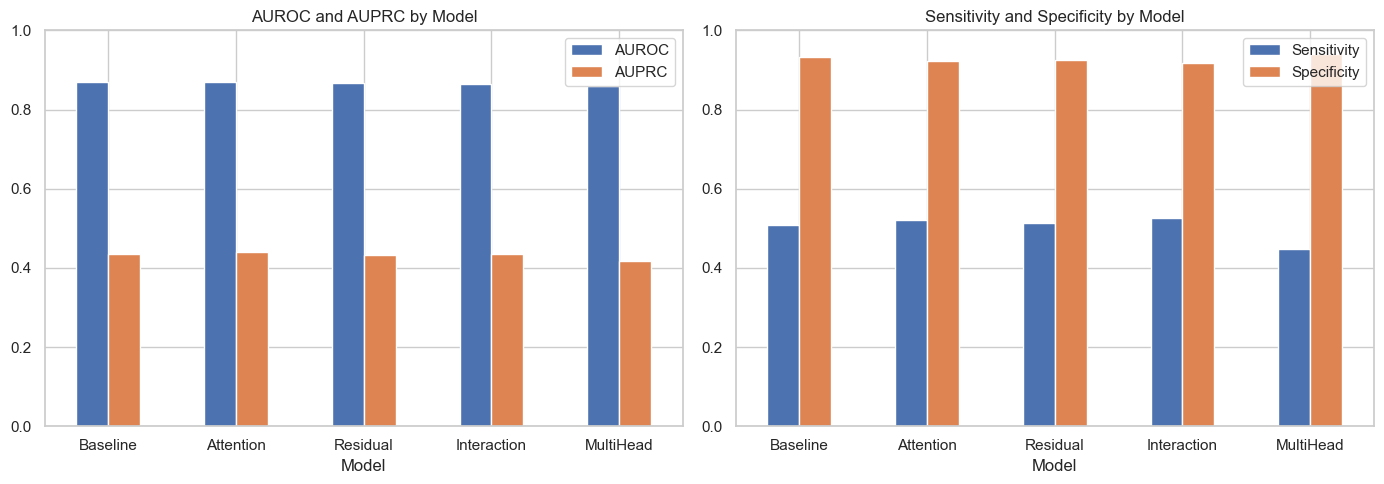

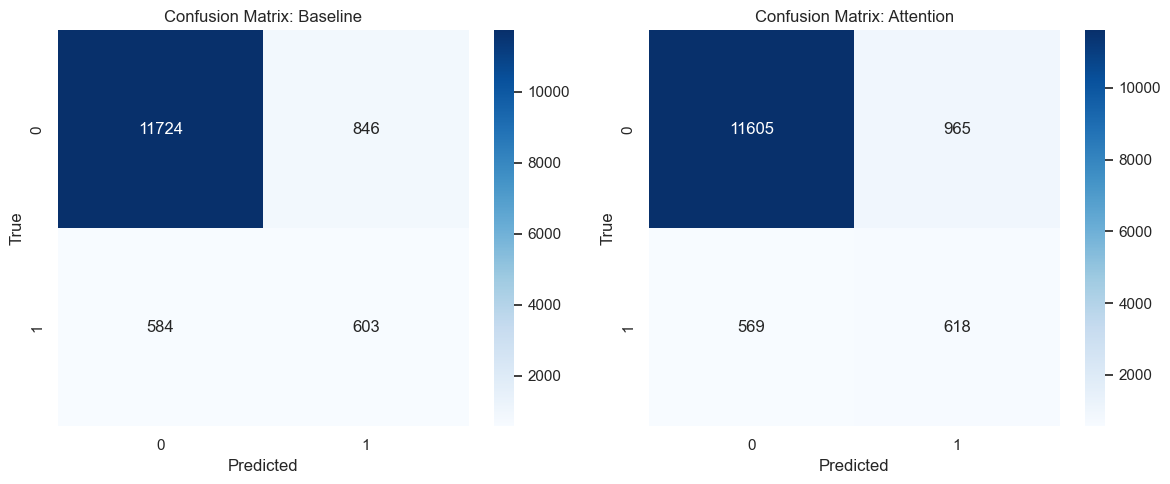

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
comparison.plot.bar(x='Model', y=['AUROC', 'AUPRC'], ax=ax[0], rot=0)
ax[0].set_title('AUROC and AUPRC by Model')
ax[0].set_ylim(0.0, 1.0)
comparison.plot.bar(x='Model', y=['Sensitivity', 'Specificity'], ax=ax[1], rot=0)
ax[1].set_title('Sensitivity and Specificity by Model')
ax[1].set_ylim(0.0, 1.0)
plt.tight_layout()
plt.show()

top_models = comparison['Model'].head(2).tolist()
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for idx, name in enumerate(top_models):
    model = models[name]
    _, y_true, y_proba = evaluate(model, test_loader, criterion)
    y_pred = (y_proba >= 0.5).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx])
    axes[idx].set_title(f'Confusion Matrix: {name}')
    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('True')
plt.tight_layout()
plt.show()